# 선문대학교 컴퓨터공학부
# 2022243101 최완우

### 6장. 넷플릭스 데이터 분석 프로젝트

#### **데이터 분석 라이브러리 불러오기**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### **csv 파일 불러오기**

In [4]:
netflix = pd.read_csv('5.3.1.netflix_titles.csv')
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


#### **데이터 내용 확인**

In [5]:
list(netflix.columns)

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

In [6]:
netflix.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [7]:
netflix.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


## **넷플릭스 데이터셋 결측치 처리하기**

#### **for문으로 결측치 비율 확인하기**

In [8]:
for i in netflix.columns :
    missingValueRate = netflix[i].isna().sum() / len(netflix) * 100
    if missingValueRate > 0 :
        print("{} null rate : {}%".format(i, round(missingValueRate, 2)))

director null rate : 29.91%
cast null rate : 9.37%
country null rate : 9.44%
date_added null rate : 0.11%
rating null rate : 0.05%
duration null rate : 0.03%


#### **fillna() 함수로 결측치를 다른 값으로 대체하기**

In [9]:
netflix['country'] = netflix['country'].fillna('No Data')

#### **replace() 함수로 결측치를 다른 값으로 대체하기**

In [10]:
netflix['director'] = netflix['director'].replace(np.nan, 'No Data')
netflix['cast'] = netflix['cast'].replace(np.nan, 'No Data')

#### **dropna()로 결측치를 가진 열 제거하기**

In [12]:
netflix.dropna(axis = 0, inplace = True)

#### **처리된 결측치 확인 - info()**

In [13]:
netflix.info()

<class 'pandas.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8790 non-null   str  
 1   type          8790 non-null   str  
 2   title         8790 non-null   str  
 3   director      8790 non-null   str  
 4   cast          8790 non-null   str  
 5   country       8790 non-null   str  
 6   date_added    8790 non-null   str  
 7   release_year  8790 non-null   int64
 8   rating        8790 non-null   str  
 9   duration      8790 non-null   str  
 10  listed_in     8790 non-null   str  
 11  description   8790 non-null   str  
dtypes: int64(1), str(11)
memory usage: 892.7 KB


#### **처리된 결측치 확인 - .isnull().sum()**

In [14]:
netflix.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

## **넷플릭스 피처 엔지니어링 하기**

#### **넷플릭스 시청 등급 변수 생성하기**

In [15]:
netflix['age_group'] = netflix['rating']

age_group_dic = {
    'G': 'All',
    'TV-G': 'All',
    'TV-Y': 'All',
    'PG': 'Older Kids',
    'TV-Y7': 'Older Kids',
    'TV-Y7-FV': 'Older Kids',
    'TV-PG': 'Older Kids',
    'PG-13': 'Teens',
    'TV-14': 'Young Adults',
    'NC-17': 'Adults',
    'NR': 'Adults',
    'UR': 'Adults',
    'R': 'Adults',
    'TV-MA': 'Adults'
}

netflix['age_group'] = netflix['age_group'].map(age_group_dic)
netflix.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,age_group
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Data,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Teens
1,s2,TV Show,Blood & Water,No Data,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Adults


#### **전처리가 완료된 데이터를 CSV 파일로 저장**

In [16]:
netflix.to_csv('netflix_preprocessed.csv', index = False)

#### **데이터 전처리 완료한 데이터셋 불러오기**

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

netflix = pd.read_csv('netflix_preprocessed.csv')

#### **넷플릭스 색상 시각화하기**

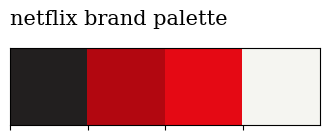

In [18]:
sns.palplot(['#221f1f', '#b20710', '#e50914', '#f5f5f1'])

plt.title('netflix brand palette', loc = 'left', fontfamily = 'serif', fontsize = 15, y = 1.2)
plt.show()

#### **넷플릭스 오징어 게임 검색하기**

In [19]:
netflix['title'].str.contains('squid game', na = False, case = False)

0       False
1       False
2       False
3       False
4       False
        ...  
8785    False
8786    False
8787    False
8788    False
8789    False
Name: title, Length: 8790, dtype: bool

In [20]:
netflix[netflix['title'].str.contains('Squid Game', na = False, case = False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,age_group
33,s34,TV Show,Squid Game,No Data,"Lee Jung-jae, Park Hae-soo, Wi Ha-jun, Oh Youn...",No Data,"September 17, 2021",2021,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Thrillers",Hundreds of cash-strapped players accept a str...,Adults


#### **넷플릭스 파이 차트 그리기**

In [21]:
type_counts = netflix['type'].value_counts()
print(type_counts)

type
Movie      6126
TV Show    2664
Name: count, dtype: int64


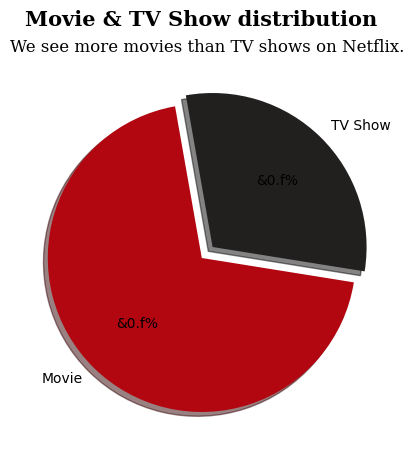

In [23]:
plt.figure(figsize = (5, 5))

plt.pie(type_counts, labels = type_counts.index, autopct = '&0.f%%', startangle = 100,
        explode = [0.05, 0.05], shadow = True, colors = ['#b20710', '#221f1f'])

plt.suptitle('Movie & TV Show distribution', fontfamily='serif', fontsize=15, fontweight='bold')
plt.title('We see more movies than TV shows on Netflix.', fontfamily = 'serif', fontsize = 12)
plt.show()

#### **넷플릭스 막대 그래프 그리기**

In [25]:
netflix.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,age_group
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Data,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Teens
1,s2,TV Show,Blood & Water,No Data,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Adults
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",No Data,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Adults


In [26]:
genres = netflix['listed_in'].str.split(', ', expand = True).stack().value_counts()
genres

International Movies            2752
Dramas                          2426
Comedies                        1674
International TV Shows          1349
Documentaries                    869
Action & Adventure               859
TV Dramas                        762
Independent Movies               756
Children & Family Movies         641
Romantic Movies                  616
Thrillers                        577
TV Comedies                      573
Crime TV Shows                   469
Kids' TV                         448
Docuseries                       394
Music & Musicals                 375
Romantic TV Shows                370
Horror Movies                    357
Stand-Up Comedy                  343
Reality TV                       255
British TV Shows                 252
Sci-Fi & Fantasy                 243
Sports Movies                    219
Anime Series                     174
Spanish-Language TV Shows        173
TV Action & Adventure            167
Korean TV Shows                  151
C

In [27]:
netflix['listed_in'].str.split(', ', expand = True)

,0,1,2
0,Documentaries,NaN,NaN
1,International TV Shows,TV Dramas,TV Mysteries
2,Crime TV Shows,International TV Shows,TV Action & Adventure
3,Docuseries,Reality TV,NaN
4,International TV Shows,Romantic TV Shows,TV Comedies
...,...,...,...
8785,Cult Movies,Dramas,Thrillers
8786,Kids' TV,Korean TV Shows,TV Comedies
8787,Comedies,Horror Movies,NaN
8788,Children & Family Movies,Comedies,NaN


In [28]:
netflix['listed_in'].str.split(', ', expand = True).stack()

0     0             Documentaries
      1                       NaN
      2                       NaN
1     0    International TV Shows
      1                 TV Dramas
                    ...          
8788  1                  Comedies
      2                       NaN
8789  0                    Dramas
      1      International Movies
      2          Music & Musicals
Length: 26370, dtype: str

In [29]:
genres = netflix['listed_in'].str.split(', ', expand = True).stack().value_counts()
genres

International Movies            2752
Dramas                          2426
Comedies                        1674
International TV Shows          1349
Documentaries                    869
Action & Adventure               859
TV Dramas                        762
Independent Movies               756
Children & Family Movies         641
Romantic Movies                  616
Thrillers                        577
TV Comedies                      573
Crime TV Shows                   469
Kids' TV                         448
Docuseries                       394
Music & Musicals                 375
Romantic TV Shows                370
Horror Movies                    357
Stand-Up Comedy                  343
Reality TV                       255
British TV Shows                 252
Sci-Fi & Fantasy                 243
Sports Movies                    219
Anime Series                     174
Spanish-Language TV Shows        173
TV Action & Adventure            167
Korean TV Shows                  151
C

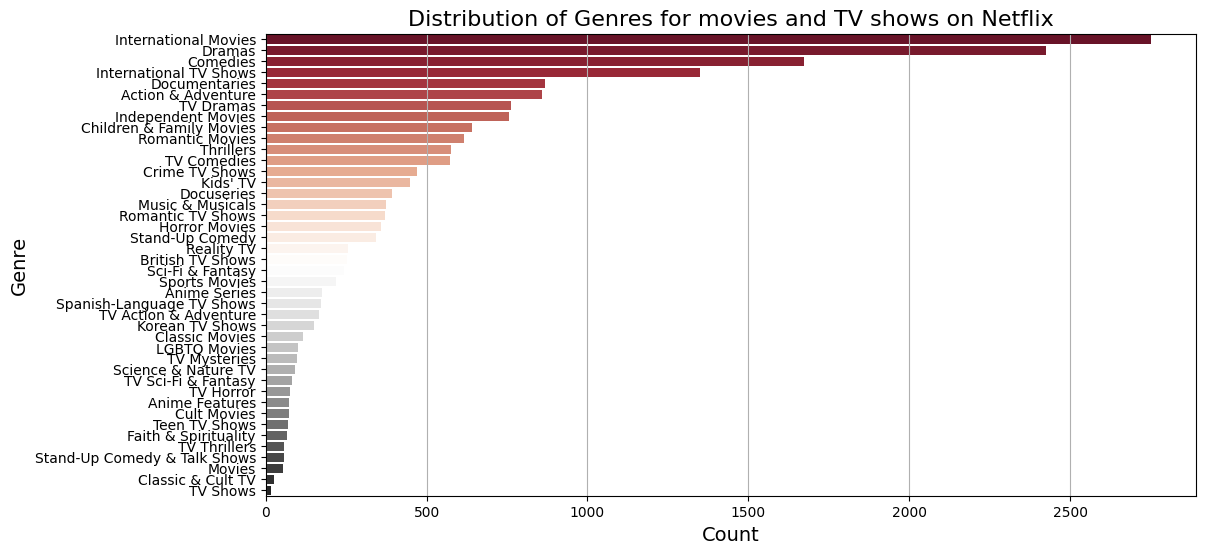

In [30]:
plt.figure(figsize = (12, 6))

sns.barplot(x = genres.values, y = genres.index, hue = genres.index, palette = 'RdGy')

plt.title('Distribution of Genres for movies and TV shows on Netflix', fontsize = 16)
plt.xlabel('Count', fontsize = 14)
plt.ylabel('Genre', fontsize = 14)
plt.grid(axis = 'x')
plt.show()

#### **넷플릭스 히트맵 그리기**

In [31]:
netflix[netflix['title'].str.contains('Sankofa', na = False, case = False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,age_group
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",Adults


In [32]:
pd.set_option('display.max_row', None)

netflix['country'] = netflix['country'].str.split(', ')
netflix['country']

0                                         [United States]
1                                          [South Africa]
2                                               [No Data]
3                                               [No Data]
4                                                 [India]
5                                               [No Data]
6                                               [No Data]
7       [United States, Ghana, Burkina Faso, United Ki...
8                                        [United Kingdom]
9                                         [United States]
10                                              [No Data]
11                                              [No Data]
12                              [Germany, Czech Republic]
13                                              [No Data]
14                                              [No Data]
15                                        [United States]
16                                              [No Data]
17            